                            Лабораторна робота №1 
                        "Зменшення розмірності даних"
                             Брильова Дар'я КН-43

 Мета роботи: Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 4)


In [2]:
#1a
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)


In [3]:
#1b
print("X shape:", X.shape)         
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))
print("Num unique labels:", len(np.unique(y)))


X shape: (70000, 784)
y shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Num unique labels: 10


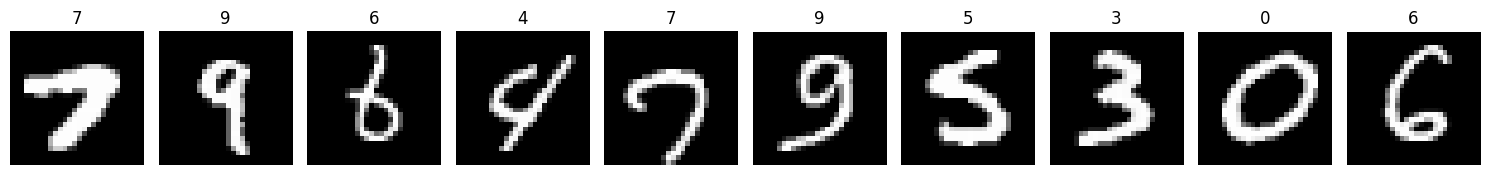

In [4]:
#1c
idx = rng.choice(X.shape[0], size=10, replace=False)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, i in zip(axes, idx):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
#2ab
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca3.fit_transform(X)

print("X_pca shape:", X_pca.shape)


X_pca shape: (70000, 3)


In [ ]:
#2c
evr = pca3.explained_variance_ratio_
print("Explained variance ratio :", evr)
print("Sum explained variance :", evr.sum())


Explained variance ratio (3 comps): [0.09746116 0.07155445 0.06149531]
Sum explained variance (3 comps): 0.230510914900965


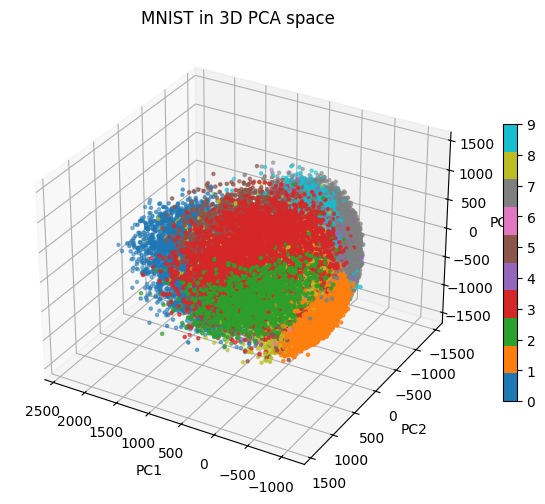

In [7]:
from mpl_toolkits.mplot3d import Axes3D  

n_plot = 70000
idx_plot = rng.choice(X.shape[0], size=n_plot, replace=False)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    X_pca[idx_plot, 0], X_pca[idx_plot, 1], X_pca[idx_plot, 2],
    c=y[idx_plot], s=5,cmap= "tab10"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("MNIST in 3D PCA space ")
plt.colorbar(sc, ax=ax, shrink=0.6)
ax.view_init(elev=30, azim=120)
plt.show()



У тривимірному просторі перших трьох компонентнів спостерігаємо часткову структурізаацію даних: кластери частково помітні,є ділянки підвищенної концентрації окремих кольорів. PCA виділяє класи посередньо, межі муж класами розмиті; дає лише грубе структурування(зменшення розмірності) але не забезпечує надійного відокремлення класів.

In [8]:
#4a
X_recon = pca3.inverse_transform(X_pca)
print("Reconstructed shape:", X_recon.shape)


Reconstructed shape: (70000, 784)


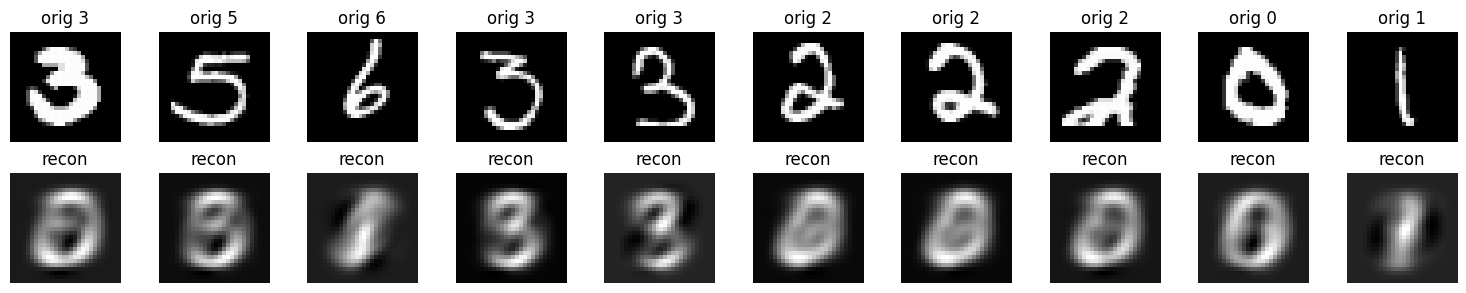

In [9]:
idx = rng.choice(X.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for col, i in enumerate(idx):
    axes[0, col].imshow(X[i].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(f"orig {y[i]}")
    axes[0, col].axis("off")
    
    axes[1, col].imshow(X_recon[i].reshape(28, 28), cmap="gray")
    axes[1, col].set_title("recon")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()


Помічаємо дуже часте відокремлення цифр під 0. Розгялнемо відношення класу "0" на 3д модели. 

C:\Users\Admin\AppData\Local\Temp\ipykernel_25768\3424754831.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(


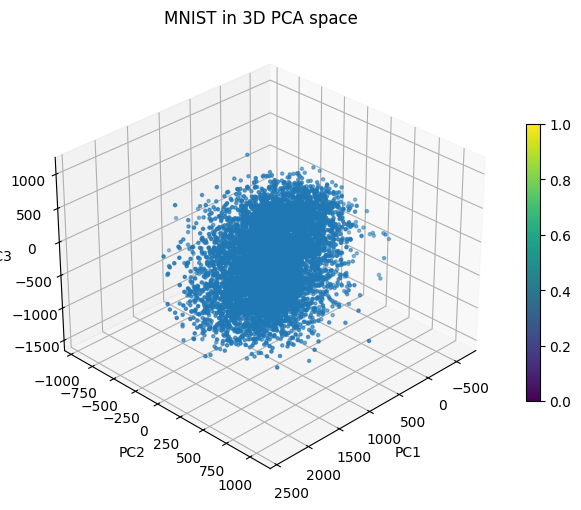

In [10]:
temp1 = pd.DataFrame(X_pca)
temp2 = pd.DataFrame(y)
temp3 = temp1.merge(temp2, how ='left', right_index=True, left_index=True)
temp3=temp3.rename(columns={'0_x': '0'})
temp3=temp3[temp3['0_y']==0]
temp3=temp3.to_numpy()

from mpl_toolkits.mplot3d import Axes3D  

n_plot =len(temp3)
idx_plot = rng.choice(temp3.shape[0], size=n_plot, replace=False)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    temp3[idx_plot, 0], temp3[idx_plot, 1], temp3[idx_plot, 2],
     s=5,cmap= "tab10"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("MNIST in 3D PCA space ")
plt.colorbar(sc, ax=ax, shrink=0.6)
ax.view_init(elev=30, azim=45)
plt.show()


In [ ]:
#кількість "0"
temp3

array([[1010.49400346,  289.96362059, -576.1207452 ,    0.        ],
       [1033.56076577,  351.18369263, -498.39574124,    0.        ],
       [ 615.42657896,  244.2202964 , -629.11004206,    0.        ],
       ...,
       [ 542.91551772,  562.03781075, -593.11903205,    0.        ],
       [1617.27790384,  327.94758828,  146.34470979,    0.        ],
       [1487.65164388,  383.66437278, -682.85634955,    0.        ]],
      shape=(6903, 4))

Можемо зазначити, що більшість цифр характеризуються як нуль через те що цей клас займає більшу умовну "площину" та все ж таки це власноруч написані цифр, ми не можемо сказати що нуль зустрічається частіше, тому що дані рівномірні, приблизно 10% кожного класу. 

In [11]:
#5b
X_eval = X

ks = [1, 2, 3, 5, 10, 20, 30, 50, 80, 100, 150, 200]
mses = []
explained = []

for k in ks:
    pca = PCA(n_components=k, random_state=RANDOM_STATE)
    Z = pca.fit_transform(X_eval)
    X_hat = pca.inverse_transform(Z)
    
    mse=np.mean((X_hat-X_eval)**2)
    mses.append(mse)
    explained.append(pca.explained_variance_ratio_.sum())

mses = np.array(mses)
explained = np.array(explained)
df = pd.DataFrame({"k": ks, "MSE": mses, "ExplainedVariance": explained})
df



,k,MSE,ExplainedVariance
0,1,3948.578013,0.097461
1,2,3635.529644,0.169016
2,3,3366.489668,0.230511
3,5,2916.204100,0.333434
4,10,2234.862667,0.489170
5,20,1554.396207,0.644707
6,30,1174.099910,0.731632
7,50,763.786890,0.825419
8,80,476.738285,0.891030
9,100,372.018316,0.914967


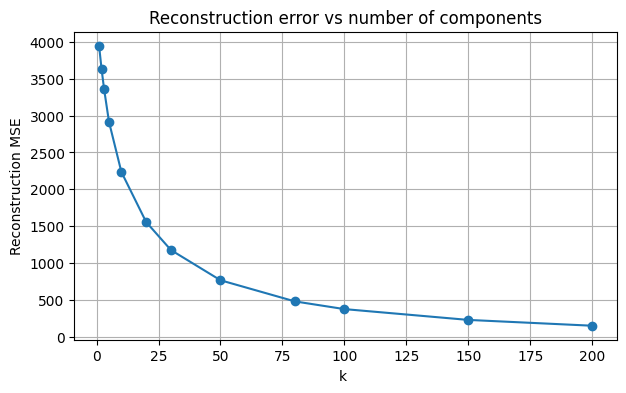

In [17]:
#Графік MSE
plt.figure(figsize=(7, 4))
plt.plot(ks, mses, marker="o")
plt.xlabel("k ")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction error vs number of components")
plt.grid(True)
plt.show()


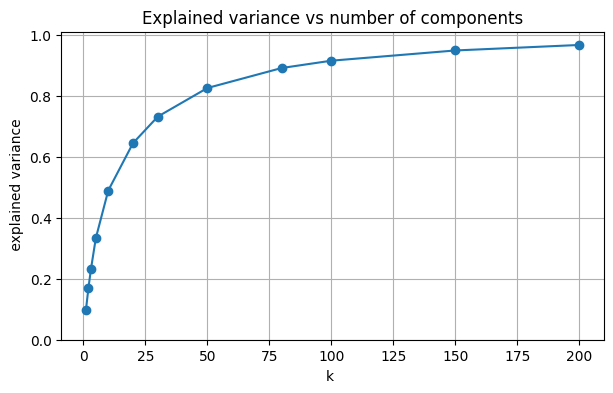

In [ ]:
#Графк поясненої дисперсії 
plt.figure(figsize=(7, 4))
plt.plot(ks, explained, marker="o")
plt.xlabel("k ")
plt.ylabel("explained variance")
plt.title("Explained variance vs number of components")
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()


Висновки: 
Для досягнення 96% дисперсії достатньо 200 компонентів.Помилка реконструкції швидко спадає на порівнянні до к=50, далі сповільнюється, мінімальне розглянуте значення при к=200, mse=146.